# 05. Rating Curve Analysis

## What You'll Learn

This notebook uses `RMC.BestFit.Model.RatingCurve` directly for stage-discharge prediction and residual diagnostics.

The parameter vector is calibrated against the model's own `LogLikelihood` and evaluated with `Predict` and `Residuals`.

# Set Up

In [4]:
import pythonnet
pythonnet.load("netfx")

import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_donet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

from System import DateTime, Double
from System.Collections.Generic import List
from scipy.optimize import minimize
from Numerics.Data import TimeSeries, TimeInterval
from RMC.BestFit.Model import RatingCurve

In [5]:
rng = np.random.default_rng(5)
stage = np.linspace(0.6, 5.0, 70)
q_true = np.where(stage < 2.2, 18*(stage-0.3)**1.7, 65*(stage-0.3)**1.15)
q_obs = np.maximum(0.1, q_true * (1 + rng.normal(0, 0.08, len(stage))))

stage_ts = TimeSeries(TimeInterval.OneDay, DateTime(2000,1,1), convert_to_donet_array(stage))
q_ts = TimeSeries(TimeInterval.OneDay, DateTime(2000,1,1), convert_to_donet_array(q_obs))

curve = RatingCurve(stage_ts, q_ts, 2)
curve.SetDefaultParameters()

x0 = np.array([float(p.Value) for p in curve.Parameters], dtype=float)
lower = np.array([float(p.LowerBound) for p in curve.Parameters], dtype=float)
upper = np.array([float(p.UpperBound) for p in curve.Parameters], dtype=float)

# A physically informed starting guess (clipped to model bounds)
x_guess = np.array([np.log10(18), 1.7, 0.3, np.log10(65), 1.15, 2.2, 0.2], dtype=float)
x_guess = np.clip(x_guess, lower + 1e-6, upper - 1e-6)

def objective(x):
    if np.any(x < lower) or np.any(x > upper):
        return 1e12
    try:
        ll = float(curve.LogLikelihood(convert_to_donet_array(x)))
        return -ll if np.isfinite(ll) else 1e12
    except Exception:
        return 1e12

fit = minimize(objective, x_guess, method='Powell', bounds=list(zip(lower, upper)), options={'maxiter': 3000})
p_hat = fit.x

pred = np.array([float(curve.Predict(convert_to_donet_array(p_hat), float(h))) for h in stage])
residuals = np.array(list(curve.Residuals(convert_to_donet_array(p_hat))), dtype=float)
rmse = float(np.sqrt(np.mean(residuals**2)))

print('Optimization success:', fit.success)
print('Optimized parameter vector:', np.round(p_hat, 5))
print('RMSE:', round(rmse, 3))

Optimization success: True
Optimized parameter vector: [1.23983 1.76225 0.28652 2.01397 0.17684 2.19425 0.03076]
RMSE: 0.031


c:\Users\q0rmcssn\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_optimize.py:2356: RuntimeWarning: overflow encountered in scalar multiply
  r = (xf - nfc) * (fx - ffulc)
c:\Users\q0rmcssn\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_optimize.py:2357: RuntimeWarning: overflow encountered in scalar multiply
  q = (xf - fulc) * (fx - fnfc)
c:\Users\q0rmcssn\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_optimize.py:2358: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
c:\Users\q0rmcssn\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_optimize.py:2359: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)
c:\Users\q0rmcssn\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_optimize.py:2359: RuntimeWarning: overflow encountered in scalar multiply
  q = 2.0 * (q - r)
c:\Users\q0rmcssn

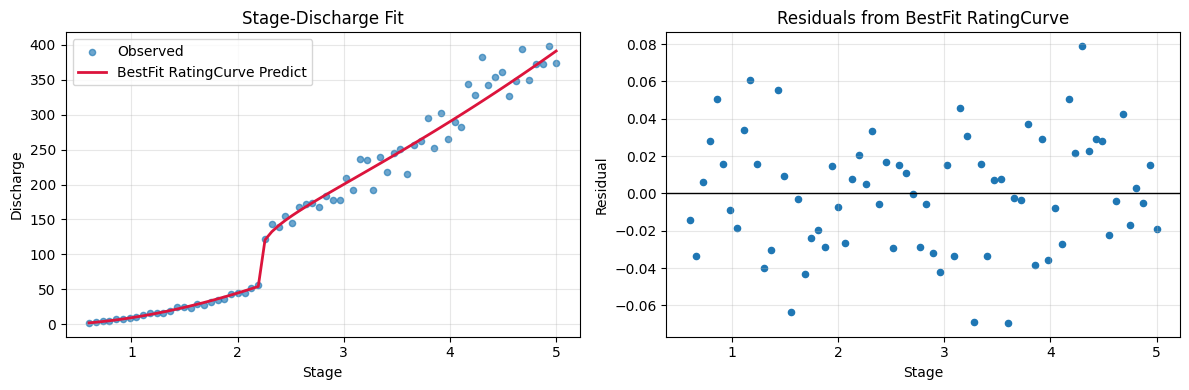

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].scatter(stage, q_obs, s=20, alpha=0.65, label='Observed')
ax[0].plot(stage, pred, color='crimson', lw=2, label='BestFit RatingCurve Predict')
ax[0].set_title('Stage-Discharge Fit')
ax[0].set_xlabel('Stage')
ax[0].set_ylabel('Discharge')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].axhline(0.0, color='black', lw=1)
ax[1].scatter(stage, residuals, s=20)
ax[1].set_title('Residuals from BestFit RatingCurve')
ax[1].set_xlabel('Stage')
ax[1].set_ylabel('Residual')
ax[1].grid(alpha=0.3)

plt.tight_layout()

## Summary and Exercises

You calibrated and diagnosed a BestFit `RatingCurve` model using its own likelihood and prediction interfaces.

Recommended exercises:
1. Repeat with `NumberOfSegments=3` and compare RMSE.
2. Hold out high-stage observations and inspect extrapolation stability.
3. Export a rating table at 0.1-stage increments using `Predict`.